##GLUE method

# IMPORT LIBRARIES

In [ ]:
import os
import time
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize, Bounds
from numba import njit, prange
from google.colab import drive, files

# Settings & Configurations
warnings.filterwarnings("ignore")
import matplotlib
matplotlib.use("Agg")

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##CAMELS-DATA from my Google Drive.

In [ ]:
# ==============================
# Paths to ZIP files
# ==============================
hydro_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/05_hydrometeorology.zip"
streamflow_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/03_streamflow.zip"

# Data extraction directories
hydro_dir = "/content/05_hydro"
streamflow_dir = "/content/03_streamflow"

# ==============================
# Function to extract ZIP files
# ==============================
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"✅ ZIP extracted in {extract_to}")
    else:
        print(f"✅ Directory {extract_to} already exists")

def find_csv(base_dir, csv_name):
    # Recursive search for the CSV file
    for root, dirs, files in os.walk(base_dir):
        if csv_name in files:
            return os.path.join(root, csv_name)
    raise FileNotFoundError(f"{csv_name} not found in {base_dir}")

# ==============================
# Extraction
# ==============================
extract_zip(hydro_zip, hydro_dir)
extract_zip(streamflow_zip, streamflow_dir)

# ==============================
# Load the 222 basins data
# ==============================
file_path = '/content/drive/MyDrive/Colab Notebooks/Dimension/id_name_metadata.csv'
basin222 = pd.read_csv(file_path)
station_ids_v1 = basin222['station_id'].astype(str).str.strip().unique()
print(f"✅ {len(station_ids_v1)} official basins loaded")

# ==============================
# 1️⃣ Precipitation (SILO)
# ==============================
precip_file = find_csv(hydro_dir, "precipitation_SILO.csv")
precip = pd.read_csv(precip_file, index_col=0, parse_dates=True)
precip.columns = precip.columns.str.strip()
precip.replace(-99.99, np.nan, inplace=True)
print("✅ SILO precipitation:", precip.shape)

# ==============================
# 2️⃣ Evapotranspiration (ET SILO)
# ==============================
et_file = find_csv(hydro_dir, "et_morton_actual_SILO.csv")
et = pd.read_csv(et_file, index_col=0, parse_dates=True)
et.columns = et.columns.str.strip()
et.replace(-99.99, np.nan, inplace=True)
print("✅ SILO ET:", et.shape)

# ==============================
# 3️⃣ Streamflow
# ==============================
streamflow_file = find_csv(streamflow_dir, "streamflow_mmd.csv")
Q = pd.read_csv(streamflow_file, index_col=0, parse_dates=True)
Q.columns = Q.columns.str.strip()
Q.replace(-99.99, np.nan, inplace=True)
print("✅ Streamflow:", Q.shape)

# ==============================
# 4️⃣ Identify common stations
# ==============================
stations_precip = set(precip.columns)
stations_et = set(et.columns)
stations_Q = set(Q.columns)

common_stations = [
    s for s in station_ids_v1
    if s in stations_precip and s in stations_et and s in stations_Q
]

print(f"✅ Official common stations: {len(common_stations)}")

# ==============================
# 5️⃣ Subset common stations
# ==============================
precip = precip[common_stations]
et = et[common_stations]
Q = Q[common_stations]

# ==============================
# 6️⃣ Final verification
# ==============================
print("Precipitation:", precip.shape)
print("ET:", et.shape)
print("Streamflow:", Q.shape)
print("Stations (first 10):", common_stations[:10], "...")


✅ Directory /content/05_hydro already exists
✅ Directory /content/03_streamflow already exists
✅ 222 official basins loaded
✅ SILO precipitation: (43464, 224)
✅ SILO ET: (43464, 224)
✅ Streamflow: (23376, 224)
✅ Official common stations: 222
Precipitation: (43464, 222)
ET: (43464, 222)
Streamflow: (23376, 222)
Stations (first 10): ['912101A', '912105A', '915011A', '917107A', '919003A', '919201A', '919309A', '922101B', '925001A', '926002A'] ...


In [ ]:
# Verification of the periods
print("Precipitation :", precip.index.min(), "→", precip.index.max())
print("ET            :", et.index.min(), "→", et.index.max())
print("Streamflow    :", Q.index.min(), "→", Q.index.max())


Precipitation : 1900-01-01 00:00:00 → 2018-01-01 00:00:00
ET            : 1900-01-01 00:00:00 → 2018-01-01 00:00:00
Streamflow    : 1951-01-01 00:00:00 → 2014-01-01 00:00:00


GLUE for GRHyMoLAP

We only consider catchments with no missing values. After calibrating the model across the available catchments, we then randomly select 4 catchments for GLUE analysis based on the defined criteria according to the intervals and thresholds.

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import numba
from numba import njit, prange
import concurrent.futures

# ── Prevent thread thrashing
numba.set_num_threads(1)

# ── Model constants
BOUNDS      = [(0.25, 2.), (0.001, 80.), (0.001, 3500.), (0.001, 18.)]
PARAM_NAMES = ["μ", "λ", "X₁", "γ"]
GUESSES     = [[0.8, 10.0, 200.0, 0.1], [1.2, 40.0, 1000.0, 0.5]]

_LO = np.array([b[0] for b in BOUNDS], dtype=np.float64)
_HI = np.array([b[1] for b in BOUNDS], dtype=np.float64)

INTERVALS  = [(0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9)]
THRESHOLDS = [0.3, 0.4, 0.5, 0.6]

# ═════════ NUMBA CORE ══════════════════════════════════════════════════════
@njit(cache=True)
def _precompute_obs_stats(Q_obs):
    mu, n = 0.0, 0
    for x in Q_obs:
        mu += x; n += 1
    mu /= n
    ss = 0.0
    for x in Q_obs:
        d = x - mu; ss += d*d
    return mu, ss

@njit(cache=True)
def _simulate(MU, LA, X1, GA, Q0, Pn, En):
    if MU <= 0.0 or LA <= 0.0 or X1 <= 0.0 or GA <= 0.0:
        return np.empty(0, dtype=np.float64)
    T = len(Pn)
    Q = np.empty(T, dtype=np.float64)
    Q[0] = Q0
    S = X1 * 0.5
    pow_exp = 2.0 * MU - 1.0
    for t in range(1, T):
        S_X1 = S / X1
        tanh_P = np.tanh(Pn[t] / X1)
        tanh_E = np.tanh(En[t] / X1)
        Ps = (X1 * (1.0 - S_X1*S_X1) * tanh_P) / (1.0 + S_X1*tanh_P)
        Es = (S * (2.0 - S_X1) * tanh_E) / (1.0 + (1.0 - S_X1)*tanh_E)
        Sc = S + Ps - Es
        ratio = (4.0 / 9.0) * (Sc / X1)
        Perc = Sc * (1.0 - (1.0 + ratio**4)**(-0.25))
        Sc -= Perc
        q = Q[t-1]
        qpow = q**pow_exp if q>0.0 else 0.0
        Q[t] = max(0.0, q - (MU/LA)*qpow + GA*Perc*Pn[t])
        S = Sc
    return Q

@njit(cache=True)
def _nse(Q_sim, Q_obs, ss_tot):
    ss_res = np.sum((Q_sim - Q_obs)**2)
    return 1.0 - ss_res/ss_tot if ss_tot>0 else np.nan

@njit(cache=True, parallel=True)
def _batch_nse_cal(samples, Q0, Pn_cal, En_cal, Q_obs_cal, ss_tot):
    N = samples.shape[0]
    out = np.empty(N, dtype=np.float64)
    for i in prange(N):
        Q = _simulate(samples[i,0], samples[i,1], samples[i,2], samples[i,3], Q0, Pn_cal, En_cal)
        out[i] = _nse(Q, Q_obs_cal, ss_tot)
    return out

@njit(cache=True, parallel=True)
def _batch_simulate(S_ens, Q0, Pn, En):
    n, T = S_ens.shape[0], len(Pn)
    Q_ens = np.empty((n,T), dtype=np.float64)
    for k in prange(n):
        Q_ens[k] = _simulate(S_ens[k,0],S_ens[k,1],S_ens[k,2],S_ens[k,3], Q0, Pn, En)
    return Q_ens

@njit(cache=True, parallel=True)
def _uniform_quantiles(Q_ens, qs):
    n, T = Q_ens.shape
    nq = len(qs)
    out = np.empty((nq,T), dtype=np.float64)
    for t in prange(T):
        col = Q_ens[:,t].copy()
        col.sort()
        for qi in range(nq):
            idx = min(n-1, int(qs[qi]*(n-1)))
            out[qi,t] = col[idx]
    return out

# ═════════ HELPERS ══════════════════════════════════════════════════════════
def _pn_en(P, PET):
    Pn = np.maximum(0.0, P-PET).astype(np.float64)
    En = np.maximum(0.0, PET-P).astype(np.float64)
    return Pn, En

def uniform_sample(N, rng):
    d = len(BOUNDS)
    S = np.empty((N,d), dtype=np.float64)
    for j,(lo,hi) in enumerate(BOUNDS):
        S[:,j] = rng.uniform(lo,hi,N)
    return S

def _param_range_widths(S_beh):
    widths = {}
    for j, name in enumerate(PARAM_NAMES):
        lo, hi = float(S_beh[:,j].min()), float(S_beh[:,j].max())
        widths[name] = {"min": lo, "max": hi, "width": hi-lo}
    return widths

# ═════════ WORKERS ══════════════════════════════════════════════════════════
def _calibrate_worker(args):
    sid, Q_obs, P, PET, b1_ratio = args
    if Q_obs.size==0:  # toutes les valeurs sont valides
        return sid, None, np.nan
    Pn, En = _pn_en(P, PET)
    T = len(Q_obs)
    b1 = max(1, int(T*b1_ratio))
    Q_cal = Q_obs[:b1]
    _, ss_cal = _precompute_obs_stats(Q_cal)

    def obj(p):
        p = np.clip(p, _LO, _HI)
        Q_sim = _simulate(p[0],p[1],p[2],p[3], Q_obs[0], Pn[:b1], En[:b1])
        v = _nse(Q_sim, Q_cal, ss_cal)
        return 1.0-v if np.isfinite(v) else 1e9

    best_val, best_x = np.inf, None
    for g in GUESSES:
        res = minimize(obj, np.clip(g,_LO,_HI), method="Nelder-Mead", options={"maxiter":2500, "disp":False})
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x.copy()
    if best_x is None or not np.all(np.isfinite(best_x)):
        return sid, None, np.nan
    best_x = np.clip(best_x,_LO,_HI)
    nse_cal = float(1.0-best_val) if best_val<1e8 else np.nan
    return sid, best_x, nse_cal

def _glue_worker(args):
    sid, Q_obs_full, P_full, PET_full, b1_ratio, theta_MAP, threshold, N_mc, seed, alpha = args
    Pn_full, En_full = _pn_en(P_full, PET_full)
    Q0 = float(Q_obs_full[0])
    T = len(Q_obs_full)
    b1 = max(1, int(T*b1_ratio)); b1 = min(b1, T-1)
    Q_cal = Q_obs_full[:b1]
    _, ss_cal = _precompute_obs_stats(Q_cal)

    rng = np.random.default_rng(seed)
    S_all = uniform_sample(N_mc, rng)
    nse_mc = _batch_nse_cal(S_all, Q0, Pn_full[:b1], En_full[:b1], Q_cal, ss_cal)
    beh_mask = nse_mc >= threshold
    n_beh = int(beh_mask.sum())
    if n_beh < 2: return None

    S_beh = S_all[beh_mask]
    Q_ens = _batch_simulate(S_beh, Q0, Pn_full, En_full)
    qs_arr = np.array([alpha/2.0, 1.0-alpha/2.0])
    Q_ptiles = _uniform_quantiles(Q_ens, qs_arr)
    Q_lo, Q_hi = Q_ptiles[0], Q_ptiles[1]
    Q_mean = Q_ens.mean(axis=0)

    # metrics
    obs_v, mean_v, lo_v, hi_v = Q_obs_full[b1:], Q_mean[b1:], Q_lo[b1:], Q_hi[b1:]
    mu_val = obs_v.mean()
    ss_tot = np.sum((obs_v - mu_val)**2)
    ss_res = np.sum((mean_v - obs_v)**2)
    NSE_mean = 1.0 - ss_res/ss_tot if ss_tot>0 else np.nan
    PICP = ((obs_v>=lo_v)&(obs_v<=hi_v)).mean()
    PIW = np.mean(hi_v-lo_v)

    return dict(
        sid=sid, theta_MAP=theta_MAP, behavioral_params=S_beh, n_behavioral=n_beh,
        threshold=threshold, param_widths=_param_range_widths(S_beh),
        Q_obs=Q_obs_full, Q_mean=Q_mean, Q_lo=Q_lo, Q_hi=Q_hi,
        b1=b1, NSE_mean=NSE_mean, PICP=PICP, PIW=PIW
    )

# ═════════ MAIN PIPELINE ════════════════════════════════════════════════════
def run_glue_selected(common_stations, Q, precip, et,
                      start_date="1980-01-01", end_date="2014-12-31",
                      b1_ratio=0.70, N_mc=100_000, seed=42, alpha=0.10,
                      out_dir="glue_results"):

    os.makedirs(out_dir, exist_ok=True)
    max_workers = os.cpu_count() or 4

    # ❌ Only consider the completed stations
    cal_args = []
    for sid in common_stations:
        try:
            q_arr = Q[sid].loc[start_date:end_date].to_numpy(dtype=float)
            p_arr = precip[sid].loc[start_date:end_date].to_numpy(dtype=float)
            e_arr = et[sid].loc[start_date:end_date].to_numpy(dtype=float)
            if np.isnan(q_arr).any() or np.isnan(p_arr).any() or np.isnan(e_arr).any():
                continue
            cal_args.append((sid, q_arr, p_arr, e_arr, b1_ratio))
        except KeyError:
            continue

    cal_results = {}
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
        for sid, theta, nse_cal in executor.map(_calibrate_worker, cal_args):
            if theta is not None and np.isfinite(nse_cal):
                cal_results[sid] = (theta, nse_cal)

    rng = np.random.default_rng(seed)
    selected_info = []
    for (lo, hi), thr in zip(INTERVALS, THRESHOLDS):
        pool = [(s,n,t) for s,(t,n) in cal_results.items() if lo<n<=hi]
        if not pool: continue
        i = int(rng.integers(0,len(pool)))
        s, n, t = pool[i]
        selected_info.append({"sid":s, "theta_MAP":t, "nse_cal":n, "interval":(lo,hi), "threshold":thr})

    if not selected_info: return None, None, None

    glue_args = []
    for info in selected_info:
        sid = info["sid"]
        q_arr = Q[sid].loc[start_date:end_date].to_numpy(dtype=float)
        p_arr = precip[sid].loc[start_date:end_date].to_numpy(dtype=float)
        e_arr = et[sid].loc[start_date:end_date].to_numpy(dtype=float)
        glue_args.append((sid,q_arr,p_arr,e_arr,b1_ratio,info["theta_MAP"],info["threshold"],N_mc,seed,alpha))

    glue_results = []
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
        for res, info in zip(executor.map(_glue_worker, glue_args), selected_info):
            if res is not None:
                res["nse_cal"], res["interval"] = info["nse_cal"], info["interval"]
                glue_results.append(res)

    # ── Display Metrics
    rows = []
    for r in glue_results:
        pw = r["param_widths"]
        row = {
            "Station": r["sid"],
            "Interval": f"({r['interval'][0]:.1f},{r['interval'][1]:.1f}]",
            "NSE_cal": round(r["nse_cal"],4),
            "Threshold": r["threshold"],
            "n_beh": r["n_behavioral"],
        }
        row.update({f"Δ{n}": round(pw[n]["width"],4) for n in PARAM_NAMES})
        rows.append(row)

    df_metrics = pd.DataFrame(rows)
    print(df_metrics.to_string(index=False))
    df_metrics.to_csv(os.path.join(out_dir,"glue_metrics.csv"), index=False)

    # ── Save full station results
    output = {r["sid"]: {"theta_MAP": r["theta_MAP"], "behavioral_params": r["behavioral_params"],
                         "param_widths": r["param_widths"],
                         "PICP": r["PICP"], "PIW": r["PIW"],
                         "Q_obs": r["Q_obs"], "Q_mean": r["Q_mean"],
                         "Q_lo": r["Q_lo"], "Q_hi": r["Q_hi"]} for r in glue_results}

    return glue_results, output, df_metrics

In [ ]:
# ── Execution bloc ─────────────────────────
if __name__ == "__main__":
    glue_results, output, df_metrics = run_glue_selected(
        common_stations = common_stations,
        Q               = Q,
        precip          = precip,
        et              = et,
        start_date      = "1980-01-01",
        end_date        = "2014-12-31",
        b1_ratio        = 0.70,
        N_mc            = 100000,
        seed            = 15,  #14
        alpha           = 0.10,      # for 90% PI
        out_dir         = "glue_results"
    )

    if glue_results is None or not output:
        print("Aucun résultat GLUE disponible pour les stations sélectionnées.")
    else:
        print("\n===== Résultats détaillés GLUE par bassin =====")
        for r in glue_results:
            print(f"\nStation: {r['sid']}")
            print(f"  NSE_calibration : {r.get('nse_cal', np.nan):.4f}")
            print(f"  n_behavioral    : {r.get('n_behavioral', 0)}")
            print("  Paramètres comportementaux (min/max/range) :")
            for pname in PARAM_NAMES:
                w = r["param_widths"].get(pname, {})
                print(f"    {pname}: min={w.get('min',np.nan):.3f}, max={w.get('max',np.nan):.3f}, width={w.get('width',np.nan):.3f}")

 Station  Interval  NSE_cal  Threshold  n_beh     Δμ      Δλ       ΔX₁      Δγ
  223202 (0.5,0.6]   0.5474        0.3     22 1.0819 22.9296 2793.5433  0.1608
  221210 (0.6,0.7]   0.6635        0.4     31 0.6341 25.3094 3093.1858  0.4503
A5030502 (0.7,0.8]   0.7963        0.5     24 0.5222 14.7445 3057.0510  0.2185
  613002 (0.8,0.9]   0.8574        0.6     57 1.0955 64.2597 3431.2449 11.4767

===== Résultats détaillés GLUE par bassin =====

Station: 223202
  NSE_calibration : 0.5474
  n_behavioral    : 22
  Paramètres comportementaux (min/max/range) :
    μ: min=0.709, max=1.790, width=1.082
    λ: min=3.309, max=26.238, width=22.930
    X₁: min=126.920, max=2920.463, width=2793.543
    γ: min=0.013, max=0.174, width=0.161

Station: 221210
  NSE_calibration : 0.6635
  n_behavioral    : 31
  Paramètres comportementaux (min/max/range) :
    μ: min=0.843, max=1.477, width=0.634
    λ: min=0.556, max=25.865, width=25.309
    X₁: min=37.376, max=3130.562, width=3093.186
    γ: min=0.120, ma

## Metrics over the validation period

In [ ]:
import pandas as pd
import numpy as np

print("===== GLUE METRICS (VALIDATION PERIOD) =====")

stations = list(output.keys())

picp_dict = {sid: output[sid]["PICP"] for sid in stations}
piw_dict  = {sid: output[sid]["PIW"]  for sid in stations}

# ── SUMMARY TABLE ──
summary = pd.DataFrame({
    "Station": stations,
    "PICP": [picp_dict[sid] for sid in stations],
    "PIW":  [piw_dict[sid] for sid in stations]
})

print(summary)

# ── GLOBAL AVERAGE ──
global_picp = np.mean(list(picp_dict.values()))
global_piw  = np.mean(list(piw_dict.values()))

print("\n===== GLOBAL METRICS =====")
print(f"Mean PICP = {global_picp:.3f}")
print(f"Mean PIW  = {global_piw:.3f}")

===== GLUE METRICS (VALIDATION PERIOD) =====
    Station      PICP       PIW
0    223202  0.842805  0.287243
1    221210  0.834724  0.959257
2  A5030502  0.836288  0.566330
3    613002  0.666840  0.622886

===== GLOBAL METRICS =====
Mean PICP = 0.795
Mean PIW  = 0.609


## PLot over last two years

===== PLOTS GLUE PAR STATION =====


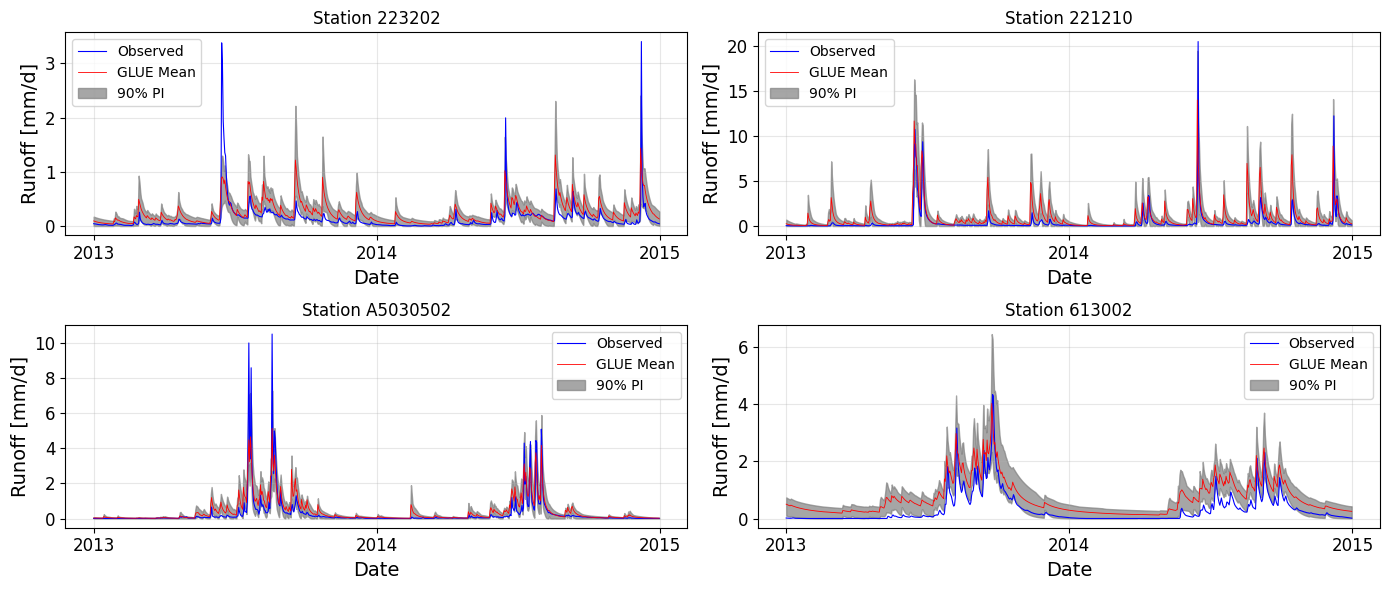

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

print("===== PLOTS GLUE PAR STATION =====")

n_days = 365 + 365
stations = list(output.keys())[:4]
dates = pd.date_range(start="2013-01-01", end="2014-12-31", freq="D")

fig, axes = plt.subplots(2, 2, figsize=(14,6))
axes = axes.flatten()

for ax, sid in zip(axes, stations):
    res = output[sid]

    Q_obs  = np.array(res["Q_obs"], dtype=float)[-n_days:]
    Q_mean = np.array(res["Q_mean"], dtype=float)[-n_days:]
    Q_lo   = np.array(res["Q_lo"], dtype=float)[-n_days:]
    Q_hi   = np.array(res["Q_hi"], dtype=float)[-n_days:]

    valid = ~np.isnan(Q_obs)

    ax.plot(dates, Q_obs, label="Observed", color="blue", linewidth=0.8)
    ax.plot(dates, Q_mean, label="GLUE Mean", color="red", linewidth=0.6)

    ax.fill_between(dates[valid], Q_lo[valid], Q_hi[valid],
                    alpha=0.7, color="gray", label="90% PI")

    ax.set_title(f"Station {sid}")
    ax.set_ylabel("Runoff [mm/d]", fontsize=14)
    ax.set_xlabel("Date", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig("glue.jpeg", dpi=700)
plt.show()

===== PLOT GLUE - 2ème STATION UNIQUEMENT (2013–2014) =====


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

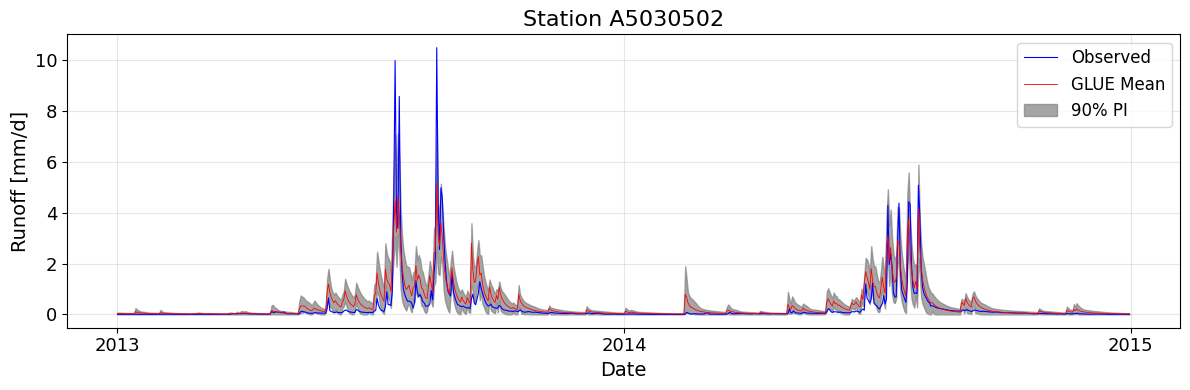

In [ ]:
%matplotlib inline

print("===== PLOT GLUE - 2ème STATION UNIQUEMENT (2013–2014) =====")

n_days = 365 + 365

stations = list(output.keys())
sid = stations[2]

dates = pd.date_range(start="2013-01-01", end="2014-12-31", freq="D")

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

res = output[sid]

Q_obs  = np.array(res["Q_obs"], dtype=float)[-n_days:]
Q_mean = np.array(res["Q_mean"], dtype=float)[-n_days:]
Q_lo   = np.array(res["Q_lo"], dtype=float)[-n_days:]
Q_hi   = np.array(res["Q_hi"], dtype=float)[-n_days:]

ax.plot(dates, Q_obs,  label="Observed", color="blue", linewidth=0.8)
ax.plot(dates, Q_mean, label="GLUE Mean", color="red", linewidth=0.6)

valid = ~np.isnan(Q_obs)
ax.fill_between(dates[valid], Q_lo[valid], Q_hi[valid],
                alpha=0.7, color="gray", label="90% PI")

ax.set_title(f"Station {sid}", fontsize=16)
ax.set_ylabel("Runoff [mm/d]", fontsize=14)
ax.set_xlabel("Date", fontsize=14)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

# ── Années seulement sur l'axe x
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig("glue.jpeg", dpi=700)
#files.download("glue.jpeg")
plt.show()